In [45]:
import numpy as np 
#import cupy as cp
import matplotlib.pyplot as plt
from scipy.special import jv

import os
import re
import sys

(0.0, -2.5)

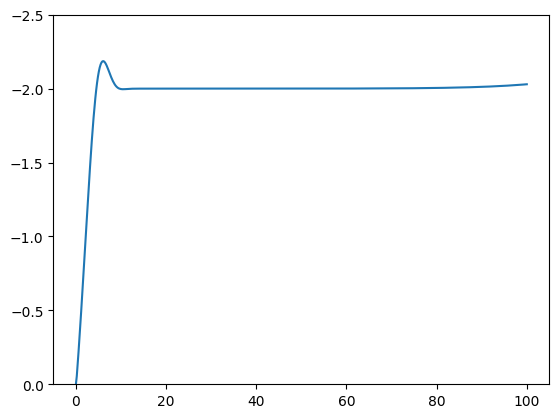

In [49]:
E = 200
z = 0.5
Lp = 2.0 * E * z * (1 - z)
Lp2 = 2.0 * E * z * (1 - z)
omega = E * z * (1 - z)
vertex = "q_qg"
t = 4
Np = 512

#htl_str = "data/fsol_final_htl_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_1.5_mu_0.2.dat"
yuk_str = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_1.5_mu_0.4.dat"
yuk_str2 = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_" + str(z) + "_q_1.5_mu_0.3.dat"
yuk_str3 = "data/fsol_final_yuk_" + vertex + "__E_" + str(int(E)) + "_z_0.4_q_1.5_mu_0.3.dat"

ho_str = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.5_q_1.5_mu_0.4.dat"
# ho_str2 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.9.dat"
# ho_str3 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.3.dat"
# ho_str4 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.15.dat"
#ho_str4 = "data/fsol_final_ho_" + vertex + "__E_" + str(int(E)) + "_z_0.3_q_1.5_mu_0.06.dat"


#htl = np.loadtxt(htl_str).T[0] + 1j * np.loadtxt(htl_str).T[1]
yuk = np.loadtxt(yuk_str).T[0] + 1j * np.loadtxt(yuk_str).T[1]
yuk2 = np.loadtxt(yuk_str2).T[0] + 1j * np.loadtxt(yuk_str2).T[1]
yuk3 = np.loadtxt(yuk_str3).T[0] + 1j * np.loadtxt(yuk_str3).T[1]

ho  = np.loadtxt(ho_str).T[0] + 1j * np.loadtxt(ho_str).T[1]
# ho2  = np.loadtxt(ho_str2).T[0] + 1j * np.loadtxt(ho_str2).T[1]
# ho3  = np.loadtxt(ho_str3).T[0] + 1j * np.loadtxt(ho_str3).T[1]
# ho4  = np.loadtxt(ho_str4).T[0] + 1j * np.loadtxt(ho_str4).T[1]

#Np = len(yuk)
P = np.linspace(0, Lp, Np, dtype=np.float64)
P2 = np.linspace(0, Lp2, Np, dtype=np.float64)

plt.plot(P2, P2/omega * np.real(yuk3), label="yukawa mu=0.3")
plt.ylim(0, -2.5)



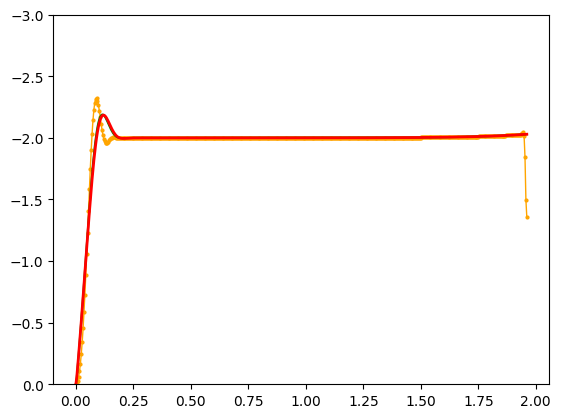

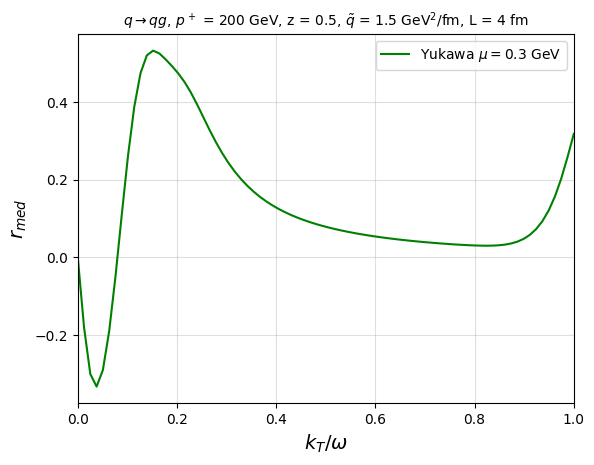

/tmp/ipykernel_2481420/3508058340.py:123: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


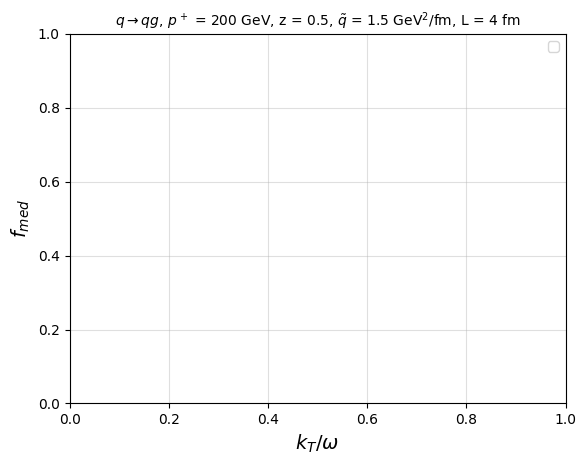

In [50]:
from scipy.interpolate import CubicSpline

#interpolate P[:-10]/omega , P[:-10]/omega*np.real(yuk[:-10]) with spline 
#data_ho = np.loadtxt("data/fsol3D_final_ho_q_qg__E_200_z_0.5_q_1.5_mu_0.4_L_4.dat").T
#data_yuk = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.01_q_1.5_mu_0.3_L_4.dat").T
#data_yuk2 = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.5_q_1.5_mu_0.3_L_4.dat").T
data_yuk3 = np.loadtxt("data/fsol3D_final_yuk_q_qg__E_200_z_0.4_q_1.5_mu_0.3_L_4.dat").T

#data_htl = np.loadtxt("data/fsol3D_final_htl_q_qg__E_200_z_0.5_q_1.5_mu_0.4.dat").T


K = P[:-10] / omega
K2 = P2[:-10] / omega
In_out_ho = P[:-10]/omega * np.real(ho[:-10])
In_out_yuk = P[:-10]/omega*np.real(yuk[:-10])
In_out_yuk2 = P[:-10]/omega*np.real(yuk2[:-10])
In_out_yuk3 = P2[:-10]/omega*np.real(yuk3[:-10])

#In_out_htl = P[:-10]/omega * np.real(htl[:-10])


plt.plot(P[:-10] / omega, In_out_ho, marker = 'o', linewidth = 1, markersize = 2, label='HO', color = "orange")
plt.plot(P[:-10] / omega, In_out_yuk, markersize = 3, linewidth = 1.5, label=r'Yukawa $q = 1.5$ GeV', color = "green")
plt.plot(P[:-10] / omega, In_out_yuk2, markersize = 3, linewidth = 2, label=r'Yukawa $q = 1.5$ GeV', color = "red")
plt.ylim(0, -3)
plt.show()

_ho_cs = CubicSpline(K, In_out_ho, extrapolate=False)
_yuk_cs = CubicSpline(K, In_out_yuk, extrapolate=False)
_yuk2_cs = CubicSpline(K, In_out_yuk2, extrapolate=False)
_yuk3_cs = CubicSpline(K2, In_out_yuk3, extrapolate=False)

#_htl_cs = CubicSpline(K, In_out_htl, extrapolate=True)


ratio = 0.5
#Kout = np.linspace(0, ratio * Lp, 60, dtype=np.float64)
N = len(K)


#f_in_yuk = data_yuk.T
#f_in_yuk2 = data_yuk2.T
f_in_yuk3 = data_yuk3.T

#f_in_ho = data_ho.T
#f_in_htl = data_htl.T

#f_out_yuk = np.zeros_like(f_in_yuk)
#f_out_yuk2 = np.zeros_like(f_in_yuk)
f_out_yuk3 = np.zeros_like(f_in_yuk3)
#f_out_ho = np.zeros_like(f_in_ho)
#f_out_htl = np.zeros_like(f_in_htl)
K = np.linspace(0, ratio * Lp2, 80, dtype=np.float64)

for i in range(len(K)):
    #f_out_yuk[i] = _yuk_cs(K[i]/omega)
    #f_out_yuk2[i] = _yuk2_cs(K[i]/omega)
    f_out_yuk3[i] = _yuk3_cs(K[i]/omega)
    #f_out_ho[i] = _ho_cs(K[i]/omega)
    #f_out_htl[i] = _htl_cs(K[i]/omega)


# d = f_in_yuk
# d2 = f_in_yuk2
# d3 = f_in_yuk3
# for _ in range(4):
#     d = np.gradient(K**2/omega**2 * d, K/omega, axis=0)
#     d2 = np.gradient(K**2/omega**2 * d2, K/omega, axis=0)
#     d3 = np.gradient(K**2/omega**2 * d3, K/omega, axis=0)
# f_in_yuk_d4 = d
# f_in_yuk2_d4 = d2
# f_in_yuk3_d4 = d3

# quick check
# print("f_in_yuk_d4.shape =", f_in_yuk_d4.shape)
# print("f_in_yuk_d4 (first 5 rows):\n", f_in_yuk_d4[:5])

# #plt.plot(f_in_yuk)
# #plt.plot(f_in_yuk_d4)

# unc = (0.5 * f_in_yuk_d4) * (K[1]-K[0])/omega
# unc2 = (0.5 * f_in_yuk2_d4) * (K[1]-K[0])/omega
# unc3 = (0.5 * f_in_yuk3_d4) * (K[1]-K[0])/omega




#plt.plot(K/omega,  (f_out_ho + 0.5 * K**2 / omega**2 * f_in_ho), marker = 'o', linewidth = 1, markersize = 2, label='HO', color = "orange")
plt.plot(K/omega,  (f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3),  markersize = 3, linewidth = 1.5, label=r'Yukawa $\mu = 0.3$ GeV', color = "green")
#plt.fill_between(K/omega, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) + unc, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) - unc, color = "green", alpha = 0.3)
#plt.plot(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3), markersize = 3, linewidth = 2, label=r'Yukawa $q = 1.5$ GeV', color = "blue")
#plt.fill_between(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) + unc3, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) - unc3, color = "blue", alpha = 0.3)
#plt.plot(K/omega, (f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2), markersize = 3, linewidth = 2, label=r'Yukawa $\mu = 0.3$ GeV', color = "red")
#plt.fill_between(K/omega, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) + unc2, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) - unc2, color = "red", alpha = 0.3)


#plt.plot(K/omega, 1 + f_out_htl + 0.5 * K**2/omega**2 * f_in_htl, marker = 's', markersize = 1, linewidth = 1, linestyle = "--", label='HTL', color = "red")

plt.title(r"$q \to qg, \, p^+$ = 200 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, L = 4 fm", fontsize = 10)
plt.ylabel(r'$r_{med}$', fontsize = 14)
plt.xlabel(r'$k_T/\omega$', fontsize = 14)
plt.legend()
plt.xlim(0, 1)

plt.grid(alpha = 0.4)
plt.savefig("rmed.png", dpi=300)
plt.show()


#plt.plot(K, (1 - (1 + f_out_ho + 0.5 * K**2 / omega**2 * f_in_ho) / (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk)), marker = 'o', linewidth = 1, markersize = 2, label='HO', color = "orange")
#plt.fill_between(K/omega, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) + unc, (1 + f_out_yuk + 0.5 * K**2/omega**2 * f_in_yuk) - unc, color = "green", alpha = 0.3)
#plt.plot(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3), markersize = 3, linewidth = 2, label=r'Yukawa $q = 1.5$ GeV', color = "blue")
#plt.fill_between(K/omega, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) + unc3, (1 + f_out_yuk3 + 0.5 * K**2/omega**2 * f_in_yuk3) - unc3, color = "blue", alpha = 0.3)
#plt.plot(K/omega, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2), markersize = 3, linewidth = 2, label=r'Yukawa $q = 2.5$ GeV', color = "red")
#plt.fill_between(K/omega, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) + unc2, (1 + f_out_yuk2 + 0.5 * K**2/omega**2 * f_in_yuk2) - unc2, color = "red", alpha = 0.3)


#plt.plot(K/omega, 1 + f_out_htl + 0.5 * K**2/omega**2 * f_in_htl, marker = 's', markersize = 1, linewidth = 1, linestyle = "--", label='HTL', color = "red")

plt.title(r"$q \to qg, \, p^+$ = 200 GeV, z = 0.5, $\tilde{q}$ = 1.5 GeV$^2$/fm, L = 4 fm", fontsize = 10)
plt.ylabel(r'$f_{med}$', fontsize = 14)
plt.xlabel(r'$k_T/\omega$', fontsize = 14)
plt.legend()

plt.grid(alpha = 0.4)
plt.savefig("rmed.png", dpi=300)
plt.show()

